In [1]:
import pandas as pd
from _helper_functions import zipdf
from _helper_functions import cb
from _helper_functions import quickfig

import seaborn as sns

import matplotlib.pyplot as plt

In [ ]:
fn='supp/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
mpradf=pd.read_pickle(fn).set_index('wt-enhancer-seq')
mpradf.head()

,enhancer-id,enhancer-sites,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:0,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,OLS WT,Neural,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:1,S1-G1F-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,NaN,NaN,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,OLS:2,S1-G1R-S2-E1F-S3-E2F-S4-G2F-S5-G3F-S6,NaN,NaN,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,OLS:3,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3R-S6,NaN,NaN,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:4,S1-G1R-S2-E1R-S3-E2F-S4-G2R-S5-G3F-S6,NaN,NaN,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [3]:
wta='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
aba='abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

In [4]:
activeEn=mpradf[wta]>=1
adf=mpradf.loc[activeEn,:]

In [5]:
a,x,y,z=[],[],[],[]

for wt,abl in zipdf(adf,[wta,aba]):
    a.append(wt)

    if abl>=1:
        x.append(abl)
    elif abl>0 and abl<1: 
        y.append(abl)
    else:
        z.append(abl)

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_32974/4012041403.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['All Active\nWT ELements',


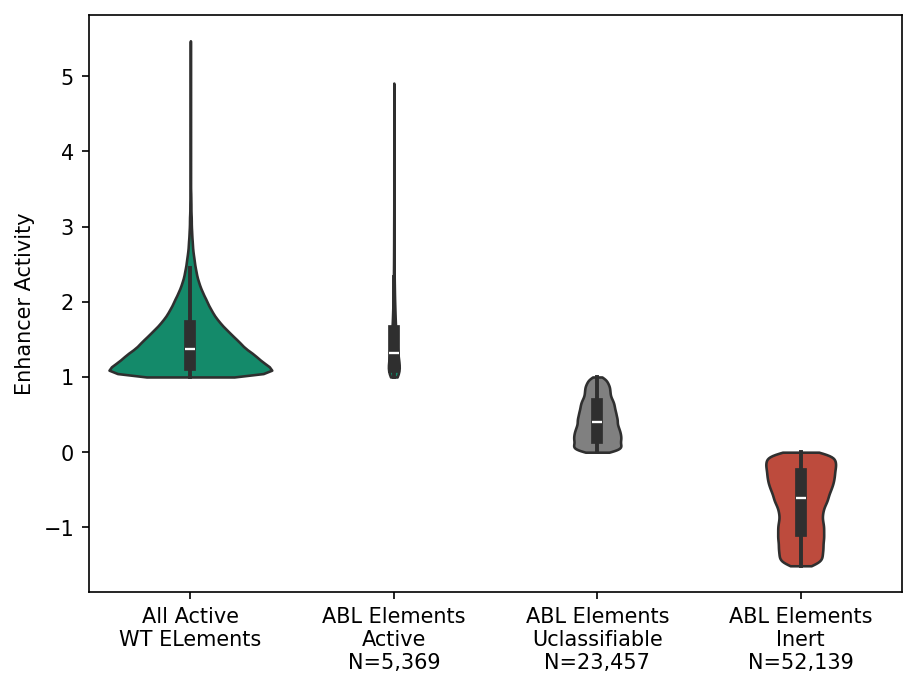

In [12]:
fig,ax=quickfig(7,5)


sns.violinplot(data=[a,x,y,z],palette=[cb['green'],cb['green'],'grey',cb['orangenature']],ax=ax, density_norm="count", common_norm=True,cut=0,)

ax.set_xticklabels(['All Active\nWT ELements',
                    f'ABL Elements\nActive\nN={len(x):,}',
                    f'ABL Elements\nUclassifiable\nN={len(y):,}',
                    f'ABL Elements\nInert\nN={len(z):,}'])

ax.set_ylabel('Enhancer Activity')

plt.show()

In [13]:
idf=mpradf.loc[mpradf[wta]<0,:]

In [14]:
a,x,y,z=[],[],[],[]

for wt,abl in zipdf(idf,[wta,aba]):
    a.append(wt)

    if abl>=1:
        x.append(abl)
    elif abl>0 and abl<1: 
        y.append(abl)
    else:
        z.append(abl)

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_32974/3152045238.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['All Inert\nWT ELements',


Text(0, 0.5, 'Enhancer Activity')

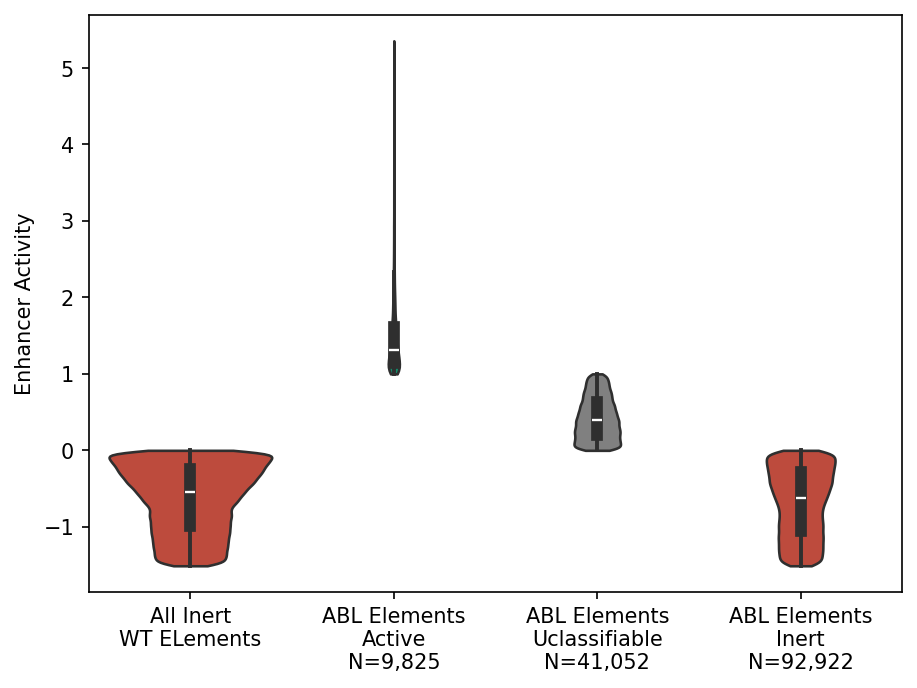

In [15]:
fig,ax=quickfig(7,5)


sns.violinplot(data=[a,x,y,z],palette=[cb['orangenature'],cb['green'],'grey',cb['orangenature']],ax=ax,density_norm="count", common_norm=True,cut=0)#scale='count')

ax.set_xticklabels(['All Inert\nWT ELements',
                    f'ABL Elements\nActive\nN={len(x):,}',
                    f'ABL Elements\nUclassifiable\nN={len(y):,}',
                    f'ABL Elements\nInert\nN={len(z):,}'])

ax.set_ylabel('Enhancer Activity')
